
|+> CIRCUIT
        ┌───┐┌───┐ ░ ┌─┐
     q: ┤ H ├┤ H ├─░─┤M├
        └───┘└───┘ ░ └╥┘
meas: 1/══════════════╩═
                      0 

|-> CIRCUIT
        ┌───┐┌───┐┌───┐ ░ ┌─┐
     q: ┤ X ├┤ H ├┤ H ├─░─┤M├
        └───┘└───┘└───┘ ░ └╥┘
meas: 1/═══════════════════╩═
                           0 

X-BASIS MEASUREMENT RESULTS

|+> STATE
0 count : 1000
1 count : 0
P(0)    : 1.0000
P(1)    : 0.0000

|-> STATE
0 count : 0
1 count : 1000
P(0)    : 0.0000
P(1)    : 1.0000


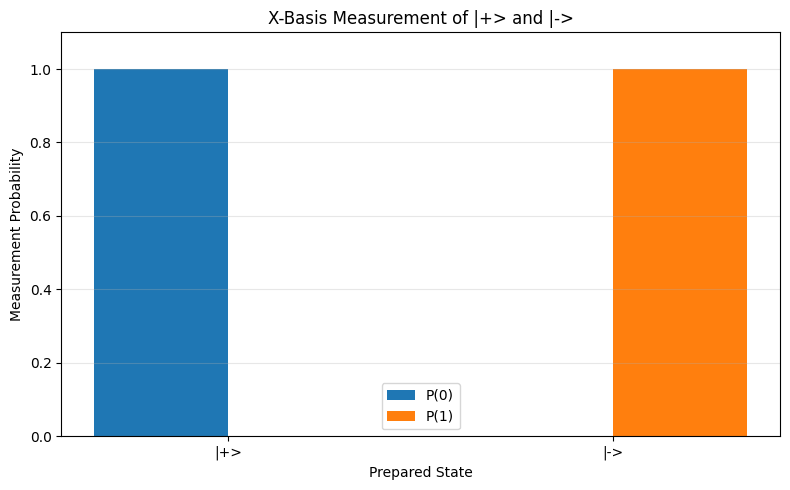

In [2]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots = 1000

sampler = StatevectorSampler()

plus = QuantumCircuit(1)

plus.h(0)
plus.h(0)

plus.measure_all()

minus = QuantumCircuit(1)

minus.x(0)
minus.h(0)
minus.h(0)

minus.measure_all()

print("\n|+> CIRCUIT")
print("=" * 50)
print(plus.draw())

print("\n|-> CIRCUIT")
print("=" * 50)
print(minus.draw())

plus_result = sampler.run(
    [plus],
    shots=shots
).result()

minus_result = sampler.run(
    [minus],
    shots=shots
).result()

plus_counts = plus_result[0].data.meas.get_counts()
minus_counts = minus_result[0].data.meas.get_counts()

plus_0 = plus_counts.get("0", 0)
plus_1 = plus_counts.get("1", 0)

minus_0 = minus_counts.get("0", 0)
minus_1 = minus_counts.get("1", 0)

plus_p0 = plus_0 / shots
plus_p1 = plus_1 / shots

minus_p0 = minus_0 / shots
minus_p1 = minus_1 / shots

print("\nX-BASIS MEASUREMENT RESULTS")
print("=" * 60)

print("\n|+> STATE")
print(f"0 count : {plus_0}")
print(f"1 count : {plus_1}")
print(f"P(0)    : {plus_p0:.4f}")
print(f"P(1)    : {plus_p1:.4f}")

print("\n|-> STATE")
print(f"0 count : {minus_0}")
print(f"1 count : {minus_1}")
print(f"P(0)    : {minus_p0:.4f}")
print(f"P(1)    : {minus_p1:.4f}")

states = ["|+>", "|->"]

prob_zero = [plus_p0, minus_p0]
prob_one = [plus_p1, minus_p1]

x = range(len(states))

plt.figure(figsize=(8, 5))

width = 0.35

plt.bar(
    [i - width / 2 for i in x],
    prob_zero,
    width=width,
    label="P(0)"
)

plt.bar(
    [i + width / 2 for i in x],
    prob_one,
    width=width,
    label="P(1)"
)

plt.xticks(list(x), states)

plt.xlabel("Prepared State")
plt.ylabel("Measurement Probability")

plt.title("X-Basis Measurement of |+> and |->")

plt.ylim(0, 1.1)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()